### 1. Environment setup

In [1]:
#1
import numpy as np
import pandas as pd
import plotly.graph_objects as go

import sys
from pathlib import Path

repo_dir = Path.cwd().parents[1]

if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

In [2]:
#2
import sys
from pathlib import Path

repo_dir = Path.cwd().parents[1]

if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

print(repo_dir)

c:\Users\au617715\Documents\MEA_experiments_analysis_code\mea_experiments


In [3]:
#3
from pv_chip_aarhus.analysis.data_io import DataIO
from pv_chip_aarhus.analysis.analysis_params import dataset_dir  # refer to your config file to
    # instead of hardcoding the paths in each script

# Initiate dataloader
data_io = DataIO(dataset_dir)

# Print available sessions
print(f'Sessions in datadir:')
for sid in data_io.sessions:
    print(f'\t{sid}')

Sessions in datadir:
	20260601_eye1_1st


In [4]:
#4
from pathlib import Path
from pv_chip_aarhus.analysis.analysis_params import dataset_dir

print("dataset_dir:")
print(dataset_dir)

print("\nExists:", Path(dataset_dir).exists())

print("\nContents:")
for f in Path(dataset_dir).iterdir():
    print(f.name)

dataset_dir:
D:\ACJ\20260601\20260601 PV chip rd1 770 eye1 1st half\Analysis\raw_filtered\dataset

Exists: True

Contents:
20260601_eye1_1st.h5


### 2. Load data (Change session IDs here)

In [5]:
#5
# ==========================================
# Load session
# ==========================================

session_id = "20260601_eye1_1st"

data_io.load_session(session_id)

print(f"Loaded session: {session_id}")
print(f"Recordings : {len(data_io.recording_df)}")
print(f"Clusters   : {len(data_io.cluster_df)}")
print(f"Trials     : {len(data_io.trial_df)}")
print(f"Bursts     : {len(data_io.burst_df)}")

Loaded session: 20260601_eye1_1st
Recordings : 15
Clusters   : 49
Trials     : 62
Bursts     : 1860


### 3. Access tables with metadata
All tables are pandas dataframes. These are the attributes I used all the time:

`df.index.values`: the index for each row, this can be used to quickly access a row

`df.loc[INDEX]`: this is how to index into a row

`df.columns`: list available columns

`df.loc[INDEX, COLUMN]` : gives value of a single cell

`df.query("COLUMN == VALUE")` : filters the dataframe based on column values

`df.iterrows()`  : allow you to loop over  each row of the table

In [6]:
#6
# ==========================================
# Recording overview
# ==========================================

print("Recording dataframe columns:")
print(data_io.recording_df.columns)

print("\nRecordings in this session:")

for row_index, row_values in data_io.recording_df.iterrows():

    print(
        f"{row_index:2d}: "
        f"{row_values['stim_file']:<45} "
        f"stimsource={row_values['stimsource']}, "
        f"varied_param={row_values['varied_param']}"
    )

Recording dataframe columns:
Index(['trigger_file', 'stim_file', 'lasermode', 'stimsource', 'laser_ch',
       'varied_param'],
      dtype='str')

Recordings in this session:
 0: 01_pow_N_P_01-06-2026_ch8_eye1_1st_half.dat   stimsource=P, varied_param=pow
 1: 01_pow_N_P_01-06-2026_ch8_eye1_1st_half.dat   stimsource=P, varied_param=pow
 2: 02_pow_N_L_01-06-2026_ch8_eye1_1st_half.dat   stimsource=L, varied_param=pow
 3: 03_pow_LC_B_01-06-2026_ch8_eye1_1st_half.dat  stimsource=B, varied_param=pow
 4: 04_dur_N_P_01-06-2026_ch8_eye1_1st_half.dat   stimsource=P, varied_param=dur
 5: 04_dur_N_P_01-06-2026_ch8_eye1_1st_half.dat   stimsource=P, varied_param=dur
 6: 05_dur_N_L_01-06-2026_ch8_eye1_1st_half.dat   stimsource=L, varied_param=dur
 7: 06_dur_LC_B_01-06-2026_ch8_eye1_1st_half.dat  stimsource=B, varied_param=dur
 8: 07_freq_N_P_01-06-2026_ch8_eye1_1st_half.dat  stimsource=P, varied_param=freq
 9: 08_freq_N_L_01-06-2026_ch8_eye1_1st_half.dat  stimsource=L, varied_param=freq
10: 09_freq_

In [7]:
#7
# Other tables we have are the cluster dataframe and the trial dataframe
# ==========================================
# Metadata summary
# ==========================================

print(f"Recording table : {data_io.recording_df.shape}")
print(f"Cluster table   : {data_io.cluster_df.shape}")
print(f"Trial table     : {data_io.trial_df.shape}")
print(f"Burst table     : {data_io.burst_df.shape}")

display(data_io.cluster_df.head())
display(data_io.trial_df.head())

Recording table : (15, 6)
Cluster table   : (49, 11)
Trial table     : (62, 15)
Burst table     : (1860, 20)


,amp,ch,depth,fr,group,n_spikes,purity,sh,phy_cluster_id,cluster_x,cluster_y
0,1033.718018,45.0,500.0,21.698162,good,59019.0,0.714743,1.0,3.0,1000.0,500.0
1,1060.319702,60.0,1500.0,30.731251,good,83589.0,0.596205,1.0,4.0,800.0,1500.0
2,742.339966,152.0,1100.0,6.902574,good,18775.0,0.665315,1.0,11.0,700.0,1100.0
3,519.447754,31.0,1100.0,15.979412,good,43464.0,0.807018,1.0,23.0,1400.0,1100.0
4,707.264343,152.0,1100.0,6.941544,good,18881.0,0.609254,1.0,49.0,700.0,1100.0


,stimsource,rec_nr,pchr_delay,pchr_on_duration,pchr_off_duration,pchr_repeats,varied_param,pchr_power,iti,laser_delay,laser_on_duration,laser_off_duration,laser_repeats,laser_power,train_id
0,P,1.0,0.0,20.0,480.0,30.0,pow,12.0,10000.0,NaN,NaN,NaN,NaN,NaN,tid_000_01
1,P,1.0,0.0,20.0,480.0,30.0,pow,25.0,10000.0,NaN,NaN,NaN,NaN,NaN,tid_001_01
2,P,1.0,0.0,20.0,480.0,30.0,pow,50.0,10000.0,NaN,NaN,NaN,NaN,NaN,tid_002_01
3,P,1.0,0.0,20.0,480.0,30.0,pow,100.0,10000.0,NaN,NaN,NaN,NaN,NaN,tid_003_01
4,P,2.0,0.0,20.0,480.0,30.0,pow,12.0,10000.0,NaN,NaN,NaN,NaN,NaN,tid_004_02


In [8]:
#8
# The most important ones are the burst dataframe, which contain the simulation onsets, and the spiketimes dict, which contains the spiketimes.

# spiketimes are stored per recording.
print("Recording IDs in spiketimes:")
print(data_io.spiketimes.keys())

print()

print(f"Number of recordings: {len(data_io.spiketimes)}")
print(f"Number of clusters: {len(data_io.cluster_df)}")

# The burst dataframe is used to get the stimulus onsets
display(data_io.burst_df.head())

Recording IDs in spiketimes:
dict_keys(['01_N_P_pow', '02_N_P_pow', '03_N_L_pow', '04_LC_B_pow', '05_N_P_dur', '06_N_P_dur', '07_N_L_dur', '08_LC_B_dur', '09_N_P_freq', '10_N_L_freq', '11_LC_B_freq', '12_N_B_del', '13_N_B_del2', '15_N_P_longstim'])

Number of recordings: 14
Number of clusters: 49


,pchr_onset,pchr_offset,stimsource,rec_nr,pchr_delay,pchr_on_duration,pchr_off_duration,pchr_repeats,varied_param,pchr_power,iti,laser_delay,laser_on_duration,laser_off_duration,laser_repeats,laser_power,train_id,rec_id,laser_onset,laser_offset
0,5997.799805,6018.049805,P,1.0,0.0,20.0,480.0,30.0,pow,12.0,10000.0,NaN,NaN,NaN,NaN,NaN,tid_000_01,01_N_P_pow,NaN,NaN
1,6498.000000,6518.100098,P,1.0,0.0,20.0,480.0,30.0,pow,12.0,10000.0,NaN,NaN,NaN,NaN,NaN,tid_000_01,01_N_P_pow,NaN,NaN
2,6998.100098,7018.149902,P,1.0,0.0,20.0,480.0,30.0,pow,12.0,10000.0,NaN,NaN,NaN,NaN,NaN,tid_000_01,01_N_P_pow,NaN,NaN
3,7498.149902,7518.250000,P,1.0,0.0,20.0,480.0,30.0,pow,12.0,10000.0,NaN,NaN,NaN,NaN,NaN,tid_000_01,01_N_P_pow,NaN,NaN
4,7998.250000,8018.299805,P,1.0,0.0,20.0,480.0,30.0,pow,12.0,10000.0,NaN,NaN,NaN,NaN,NaN,tid_000_01,01_N_P_pow,NaN,NaN


In [9]:
#9
# ==========================================
# Available recordings
# ==========================================

print("Available rec_id values:\n")

for rec in sorted(data_io.burst_df["rec_id"].unique()):
    print(rec)

Available rec_id values:

01_N_P_pow
02_N_P_pow
03_N_L_pow
04_LC_B_pow
05_N_P_dur
06_N_P_dur
07_N_L_dur
08_LC_B_dur
09_N_P_freq
10_N_L_freq
11_LC_B_freq
12_N_B_del
13_N_B_del2
15_N_P_longstim


### Example of how to load all data for the 'pow' sequence

In [10]:
# #10 control+k, then control+c to comment out the code below, control+k, then control+u to uncomment
# import numpy as np
# varied_param = 'pow'
# stimsource = 'P'
# burst_df = data_io.burst_df.query('varied_param == @varied_param and stimsource == @stimsource')
# print(f'found {burst_df.shape[0]} stimulation onsets in {len(burst_df["train_id"].unique())} trials')

# # Use the groupby function, to get stimulation onsets for each trial
# all_spiketimes = {}
# for train_id, train_df in burst_df.groupby('train_id'):

#     # Each row should have the same stimulation parameter. Normally you dont have to check this
#     # but here im checking that anyway
#     assert len(train_df['pchr_power'].unique()) == 1
#     pchr_power = train_df.iloc[0]['pchr_power']  # the iloc function returns the row based on row number, not index
#         # like with the loc function
#     rec_id = train_df.iloc[0]['rec_id']  # we need this to get the spiketimes
#     print(f'{train_id}: polychrome power: {pchr_power}')

#     # Take the first cluster in this recording, in the future we should use cluster_df to point to the cells
#     cluster_id = list(data_io.spiketimes[rec_id].keys())[0]
#     spiketrain = data_io.spiketimes[rec_id][cluster_id]

#     # Set interval from which to extract the spiketimes
#     t_pre = 100
#     t_post = 200

#     spiketimes_trial = []  # this will now contain all the spiketimes
#     for burst_i, burst_info in train_df.iterrows():
#         onset = burst_info.pchr_onset
#         idx = np.where((spiketrain >= onset - t_pre) & (spiketrain <= onset + t_post))[0]
#         spiketimes_burst = spiketrain[idx] - onset  # normalize to stimulus onset
#         spiketimes_trial.append(spiketimes_burst)

#     all_spiketimes[train_id] = spiketimes_trial

In [11]:
# #11
# import plotly.graph_objects as go

# fig = go.Figure()

# # Setup variables for plotting
# burst_offset   = 0
# x_plot, y_plot = [], []
# x_lines_laser, y_lines_laser = [], []
# x_lines_dmd, y_lines_dmd = [], []

# yticks         = []
# ytext          = []

# for train_id, spiketrains in all_spiketimes.items():
#     df = data_io.trial_df.query('train_id == @train_id')
#     stim_duration = df.iloc[0]['pchr_on_duration']
#     pchr_power = df.iloc[0]['pchr_power']

#     print(f'{train_id}, stimduration: {stim_duration:.0f}, power: {pchr_power}')

#     for burst_i, sp in enumerate(spiketrains):
#         x_plot.append(np.vstack([sp, sp, np.full(sp.size, np.nan)]).T.flatten())
#         y_plot.append(np.vstack([np.ones(sp.size) * burst_offset,
#                                 np.ones(sp.size)* burst_offset +1, np.full(sp.size, np.nan)]).T.flatten())
#         burst_offset += 1

# x_plot = np.hstack(x_plot)
# y_plot = np.hstack(y_plot)

# fig.add_scatter(
#     x=x_plot, y=y_plot,
#     mode='lines', line=dict(width=5, color='white'),
#     showlegend=False,
# )
# fig.show()


In [12]:
# #12
# # Select the recording to analyse
# rec_id = "07_N_L_dur"

# # Select the unit (cluster) within that recording
# unit_id = "uid_20260601_001"

# # Select only stimulation bursts from this recording
# burst_df = data_io.burst_df.query(
#     "rec_id == @rec_id"
# )

# if burst_df.empty:
#     raise ValueError(
#         f"Recording '{rec_id}' not found.\n"
#         f"Available recordings:\n{data_io.burst_df['rec_id'].unique()}"
#     )
# # Dictionary that will contain all spike trains
# #
# # Structure:
# # all_spiketimes[train_id] = list of spike trains
# #
# # where each list element corresponds to one stimulation burst.
# all_spiketimes = {}

# # Loop over each stimulation condition (train_id)
# for train_id, train_df in burst_df.groupby("train_id"):

#     # Load the complete spike train for this unit
#     spiketrain = data_io.spiketimes[rec_id][unit_id]

#     # Time window around each stimulus onset (ms)
#     t_pre = 100
#     t_post = 6000

#     # Will contain one aligned spike train per burst
#     spiketimes_trial = []

#     # Loop over every stimulation burst in this condition
#     for _, burst_info in train_df.iterrows():

#         # Absolute stimulus onset time
#         onset = burst_info.laser_onset

#         # Find spikes occurring within the analysis window
#         idx = np.where(
#             (spiketrain >= onset - t_pre)
#             & (spiketrain <= onset + t_post)
#         )[0]

#         # Shift spike times so that:
#         # 0 ms = stimulation onset
#         spiketimes_burst = spiketrain[idx] - onset

#         # Store this burst
#         spiketimes_trial.append(spiketimes_burst)

#     # Store all bursts belonging to this stimulation condition
#     all_spiketimes[train_id] = spiketimes_trial

In [13]:
# #13
# print(f"Recording: {rec_id}")

# available_units = list(data_io.spiketimes[rec_id].keys())

# print(f"Number of units: {len(available_units)}")
# print(available_units)

In [14]:
# #14
# print(all_spiketimes.keys())

### 4. Select recording, unit and other analysis parameters

In [15]:
#15
# Experimental recording
#
# Naming convention:
#
# XX_MODE_SOURCE_PROTOCOL
#
# Examples:
#
# 02_N_P_pow
#     Irradiance series
#     Normal pulsed stimulation
#     Polychrome only
#
# 07_N_L_dur
#     Duration series
#     Normal pulsed stimulation
#     Laser only
#
# 15_N_P_longstim
#     Long stimulation protocol
#
# ==========================================
# Analysis parameters
# ==========================================

session_id = "20260601_eye1_1st"

# Experiment to analyse
protocol = "pow"          # pow, dur, freq, del, del2, longstim
stim_mode = "L"           # P, L or B
laser_mode = "N"          # N or LC

# Optional manual override
manual_rec_id = None      # e.g. "05_N_P_dur"

# Cluster
unit_id = "uid_20260601_008"

# Analysis window (ms)
t_pre = 1000
t_post = 7000

analysis_window = (-t_pre, t_post)

### 4. Selection of parameters (Helping part)

In [16]:
#16
# ==========================================
# Select recording
# ==========================================

if manual_rec_id is not None:

    rec_id = manual_rec_id

else:

    candidates = sorted(
        rec
        for rec in data_io.spiketimes.keys()
        if (
            rec.endswith(protocol)
            and f"_{stim_mode}_" in rec
            and rec.split("_")[1] == laser_mode
        )
    )

    if len(candidates) == 0:
        raise ValueError("No matching recording found.")

    # Always use the newest repeat
    rec_id = candidates[-1]

print(f"Selected recording: {rec_id}")

Selected recording: 03_N_L_pow


In [17]:
#17
print("Current analysis")
print("----------------")
print(f"Session      : {session_id}")
print(f"Recording    : {rec_id}")
print(f"Unit         : {unit_id}")
print(f"Protocol     : {protocol}")
print(f"Stim. mode   : {stim_mode}")
print(f"Laser mode   : {laser_mode}")
print(f"Window       : {-t_pre} to +{t_post} ms")

Current analysis
----------------
Session      : 20260601_eye1_1st
Recording    : 03_N_L_pow
Unit         : uid_20260601_008
Protocol     : pow
Stim. mode   : L
Laser mode   : N
Window       : -1000 to +7000 ms


In [18]:
#18
assert rec_id in data_io.spiketimes, (
    f"{rec_id} not found.\n"
    f"Available recordings:\n"
    f"{list(data_io.spiketimes.keys())}"
)

assert unit_id in data_io.spiketimes[rec_id], (
    f"{unit_id} not found in {rec_id}"
)

In [19]:
#19
# ==========================================
# Determine stimulation metadata
# ==========================================

"""
Determine which stimulation metadata are available for the
selected recording.

This cell does not decide which stimulation source will be
analysed. Instead, it prepares metadata dictionaries that are
used later when constructing the analysis views.

Using dictionaries rather than global variables allows
combined (LC_B) recordings to expose both stimulation sources
without breaking compatibility with single-source recordings.
"""

# ------------------------------------------
# Decode recording ID
# ------------------------------------------

_, laser_mode, stim_source, protocol = rec_id.split("_")

print(f"Laser mode : {laser_mode}")
print(f"Stim source: {stim_source}")
print(f"Protocol   : {protocol}")

# ------------------------------------------
# Metadata definitions
# ------------------------------------------

pchr_columns = {

    "onset": "pchr_onset",
    "duration": "pchr_on_duration",
    "off_duration": "pchr_off_duration",
    "delay": "pchr_delay",
    "power": "pchr_power",
    "frequency": "pchr_frequency",

}

laser_columns = {

    "onset": "laser_onset",
    "duration": "laser_on_duration",
    "off_duration": "laser_off_duration",
    "delay": "laser_delay",
    "power": "laser_power",
    "frequency": "laser_frequency",

}

# ------------------------------------------
# Backwards compatibility
# ------------------------------------------

"""
Existing notebook sections expect the variables

    onset_column
    duration_column
    power_column
    frequency_column

For single-source recordings we continue defining these
variables exactly as before.

Combined recordings expose both metadata dictionaries.
The analysis_views helper will decide which metadata to use
for each analysis.
"""

if stim_source == "P":

    onset_column = pchr_columns["onset"]
    duration_column = pchr_columns["duration"]
    power_column = pchr_columns["power"]
    frequency_column = pchr_columns["frequency"]

elif stim_source == "L":

    onset_column = laser_columns["onset"]
    duration_column = laser_columns["duration"]
    power_column = laser_columns["power"]
    frequency_column = laser_columns["frequency"]

elif stim_source == "B":

    # Temporary defaults for backwards compatibility.
    # These should no longer be used by the analysis code.
    onset_column = pchr_columns["onset"]
    duration_column = pchr_columns["duration"]
    power_column = pchr_columns["power"]
    frequency_column = pchr_columns["frequency"]

else:

    raise ValueError(
        f"Unknown stimulation source: {stim_source}"
    )

print("\nAvailable metadata")

if stim_source == "B":

    print("Polychrome:")
    print(f"  onset      : {pchr_columns['onset']}")
    print(f"  duration   : {pchr_columns['duration']}")

    print("Laser:")
    print(f"  onset      : {laser_columns['onset']}")
    print(f"  duration   : {laser_columns['duration']}")

else:

    print(f"onset      : {onset_column}")
    print(f"duration   : {duration_column}")
    print(f"power      : {power_column}")
    print(f"frequency  : {frequency_column}")

Laser mode : N
Stim source: L
Protocol   : pow

Available metadata
onset      : laser_onset
duration   : laser_on_duration
power      : laser_power
frequency  : laser_frequency


### 5. Determine analysis views <- Helper cell

In [20]:
#20
# HELPER CELL
# ==========================================
# Determine recording-specific parameters
# ==========================================

"""
Prepare one or more analysis views for the selected recording.

Each analysis view contains all metadata required by the
downstream analysis.

Ordinary recordings contain one analysis view.

Combined LC_B recordings contain two independent analysis
views:

    Polychrome
    Laser

Downstream code should always obtain metadata from the
selected analysis view rather than relying on recording-level
variables.
"""

# ------------------------------------------
# Determine grouping label
# ------------------------------------------

if protocol == "pow":

    group_label = "Irradiance"

elif protocol == "dur":

    group_label = "Pulse duration (ms)"

elif protocol == "freq":

    group_label = "Pulse frequency (Hz)"

elif protocol == "longstim":

    group_label = "Stimulation duration (ms)"

elif protocol in ["del", "del2"]:

    group_label = "Delay condition"

else:

    raise ValueError(
        f"Unknown protocol: {protocol}"
    )

# ------------------------------------------
# Select bursts belonging to the recording
# ------------------------------------------

burst_df = (
    data_io.burst_df
    .query("rec_id == @rec_id")
    .copy()
)

assert not burst_df.empty, (
    f"No bursts found for recording {rec_id}"
)

# ------------------------------------------
# Helper functions
# ------------------------------------------

def build_stim_windows(burst_info, stim_source):
    """
    Determine the alignment onset and stimulation windows.

    Returns
    -------
    alignment_onset : float
        Absolute recording time used to align spikes.

    windows : list
        List of (x0, x1, label) tuples relative to the
        alignment onset.
    """

    if protocol in ["del", "del2"]:

        # Delay metadata indicate which stimulus is delayed:
        #
        # pchr_delay  > 0 : Polychrome starts after Laser
        # laser_delay > 0 : Laser starts after Polychrome
        #
        # Only one onset is stored in the metadata. The other onset is
        # reconstructed here.
        p_on = burst_info["pchr_onset"]
        l_on = burst_info["laser_onset"]

        # Delay metadata indicate which stimulus is delayed.
        # Only one onset is stored; reconstruct the other.

        if np.isnan(l_on):

            if burst_info["pchr_delay"] > 0:
                # Polychrome is delayed relative to the laser
                l_on = (
                    p_on
                    - burst_info["pchr_delay"]
                )

            else:
                # Laser is delayed relative to the polychrome
                l_on = (
                    p_on
                    + burst_info["laser_delay"]
                )

        elif np.isnan(p_on):

            if burst_info["laser_delay"] > 0:
                p_on = (
                    l_on
                    - burst_info["laser_delay"]
                )

            else:
                p_on = (
                    l_on
                    + burst_info["pchr_delay"]
                )

        alignment = min(p_on, l_on)

        p_on -= alignment
        l_on -= alignment
                

    else:

        if stim_source == "P":

            alignment = burst_info["pchr_onset"]

            p_on = 0
            l_on = None

        elif stim_source == "L":

            alignment = burst_info["laser_onset"]

            p_on = None
            l_on = 0

        else:

            raise ValueError(
                f"Unknown stimulation source: {stim_source}"
            )

    windows = []

    if p_on is not None:
        windows.append(
            (
                p_on,
                p_on + burst_info["pchr_on_duration"],
                "Polychrome",
            )
        )

    if l_on is not None:
        windows.append(
            (
                l_on,
                l_on + burst_info["laser_on_duration"],
                "Laser",
            )
        )

    return alignment, windows


def make_view(name, stim_source, columns):
    """Create one analysis view."""

    if protocol == "pow":
        group_column = columns["power"]

    elif protocol == "dur":
        group_column = columns["duration"]

    elif protocol == "freq":
        group_column = columns["frequency"]

    elif protocol == "longstim":
        group_column = columns["duration"]

    elif protocol in ["del", "del2"]:
        group_column = columns["delay"]

    else:
        raise ValueError(protocol)

    return {

        "name": name,

        "stim_source": stim_source,

        "group_column": group_column,
        "group_label": group_label,

        "onset_column": columns["onset"],

        "on_duration_column": columns["duration"],
        "off_duration_column": columns["off_duration"],

        "power_column": columns["power"],
        "frequency_column": columns["frequency"],

        # New
        "stim_windows": (
            lambda burst_info:
                build_stim_windows(
                    burst_info,
                    stim_source,
                )
        ),

    }

# ------------------------------------------
# Build analysis views
# ------------------------------------------

analysis_views = []

if stim_mode == "P":

    analysis_views.append(
        make_view(
            "Polychrome",
            "P",
            pchr_columns,
        )
    )

elif stim_mode == "L":

    analysis_views.append(
        make_view(
            "Laser",
            "L",
            laser_columns,
        )
    )

elif stim_mode == "B":

    analysis_views.append(
        make_view(
            "Polychrome",
            "P",
            pchr_columns,
        )
    )

    analysis_views.append(
        make_view(
            "Laser",
            "L",
            laser_columns,
        )
    )

else:

    raise ValueError(
        f"Unknown stimulation mode: {stim_mode}"
    )

# ------------------------------------------
# Backwards compatibility
# ------------------------------------------

current_view = analysis_views[0]

group_column = current_view["group_column"]
group_label = current_view["group_label"]

onset_column = current_view["onset_column"]

on_duration_column = current_view["on_duration_column"]
off_duration_column = current_view["off_duration_column"]

power_column = current_view["power_column"]
frequency_column = current_view["frequency_column"]

# ------------------------------------------
# Summary
# ------------------------------------------

print("Analysis views")
print("--------------")

for view in analysis_views:

    print(
        f"{view['name']:<12}"
        f" source={view['stim_source']}"
        f" group={view['group_column']}"
        f" onset={view['onset_column']}"
    )

Analysis views
--------------
Laser        source=L group=laser_power onset=laser_onset


### 6. Extract stimulus-aligned spike trains

In [21]:
#21
# ==========================================
# Extract stimulus-aligned spike trains
# ==========================================

"""
Goal
----
Convert one continuous spike train from a single unit
into many stimulus-aligned spike trains.

The original spike train contains the firing activity
throughout the entire recording.

For each stimulation burst, spikes are extracted within
a time window around stimulus onset and shifted so that

    0 ms = stimulus onset

The output is a dictionary:

all_spiketimes[train_id] = [
    burst_1_spikes,
    burst_2_spikes,
    ...
]

Each burst therefore contains spike times relative to
stimulus onset and is ready for raster plotting or
statistical analysis.
"""

assert rec_id in data_io.spiketimes, (
    f"{rec_id} not found in spiketimes."
)

assert unit_id in data_io.spiketimes[rec_id], (
    f"{unit_id} not found in recording {rec_id}."
)

# ------------------------------------------
# Extract stimulus-aligned spike trains
# ------------------------------------------

# Dictionary of extracted spike trains.
#
# Structure
# ---------
# all_spiketimes[view_name][train_id]
#
# Example
# -------
# all_spiketimes["Polychrome"]["tid_001"]
#
all_spiketimes = {}

# ------------------------------------------
# Loop over analysis views
# ------------------------------------------

for view in analysis_views:

    print(f"\nExtracting {view['name']} responses")

    # Helper describing the stimulation timing
    stim_windows = view["stim_windows"]

    # Load the complete spike train for the selected unit
    spiketrain = data_io.spiketimes[rec_id][unit_id]

    view_spiketimes = {}

    # Loop over each stimulation condition
    for train_id, train_df in burst_df.groupby("train_id"):

        spiketimes_trial = []

        # Loop over every stimulation burst
        for _, burst_info in train_df.iterrows():

            # ----------------------------------
            # Determine alignment onset
            # ----------------------------------

            alignment_onset, _ = stim_windows(
                burst_info
            )
            idx = np.where(
                (spiketrain >= alignment_onset - t_pre)
                & (spiketrain <= alignment_onset + t_post)
            )[0]

            spiketimes_burst = (
                spiketrain[idx] - alignment_onset
            )

            spiketimes_trial.append(
                spiketimes_burst
            )

        view_spiketimes[train_id] = spiketimes_trial

    all_spiketimes[view["name"]] = view_spiketimes

# ------------------------------------------
# Summary
# ------------------------------------------

print("\nExtraction complete")
print("-------------------")
print(f"Recording : {rec_id}")
print(f"Unit      : {unit_id}")

for view_name, view_data in all_spiketimes.items():

    print(f"\n{view_name}")

    for train_id, spikes in view_data.items():

        print(
            f"  {train_id}: "
            f"{len(spikes)} repetitions"
        )


Extracting Laser responses

Extraction complete
-------------------
Recording : 03_N_L_pow
Unit      : uid_20260601_008

Laser
  tid_008_03: 30 repetitions
  tid_009_03: 30 repetitions
  tid_010_03: 30 repetitions
  tid_011_03: 30 repetitions


In [22]:
#22
view_name = analysis_views[0]["name"]

train_id = next(iter(all_spiketimes[view_name]))

print("train_id:", train_id)

print("First repetition:")
print(all_spiketimes[view_name][train_id][0])

print()

print("Min:", all_spiketimes[view_name][train_id][0].min())
print("Max:", all_spiketimes[view_name][train_id][0].max())

train_id: tid_008_03
First repetition:
[-862.55 -686.1  -421.7  -226.6  -184.75 -122.65  313.45  342.35  729.
  759.75  776.4   890.3  1108.85 1445.9  1747.   1828.55 2020.3  2094.6
 2126.4  2176.65 2253.85 2313.7  2450.15 2493.35 2574.7  2623.3  2902.
 2912.55 2960.4  2980.1  3117.85 3192.6  3434.45 3461.65 3608.5  3698.6
 3843.05 3991.75 4057.4  4091.4  4136.7  4275.65 4433.05 4454.5  4489.45
 4516.15 4523.9  4638.7  4871.4  4879.05 4942.4  4952.8  5216.45 5251.
 5303.35 5347.15 5464.1  5481.1  5563.4  5600.75 5612.2  5739.25 5951.65
 6105.8  6176.55 6182.35 6235.6  6494.45 6543.25 6581.   6727.2  6938.7 ]

Min: -862.5500000000002
Max: 6938.699999999999


In [23]:
#23
first_burst = burst_df.iloc[0]

print(first_burst[[
    "train_id",
    "laser_onset",
    "laser_delay",
    "laser_on_duration",
    "laser_off_duration",
]])

train_id              tid_008_03
laser_onset               5550.0
laser_delay                  0.0
laser_on_duration           30.0
laser_off_duration         470.0
Name: 240, dtype: object


### 7. Raster plot: Single units

In [24]:
#24
print("View:", view_name)
print()

print("Grouping column :", group_column)
print("On duration     :", on_duration_column)
print("Off duration    :", off_duration_column)
print("Onset column    :", onset_column)

View: Laser

Grouping column : laser_power
On duration     : laser_on_duration
Off duration    : laser_off_duration
Onset column    : laser_onset


In [25]:
#24a

view = analysis_views[0]

print(view["name"])

for group, trains in all_spiketimes[view["name"]].items():

    print(f"\nGroup: {group}")

    print("Number of trials:", len(trains))

    print("Type of first trial:", type(trains[0]))

    print("Length of first trial:", len(trains[0]))

    print("First 10 spike times:")

    print(trains[0][:10])

    break

Laser

Group: tid_008_03
Number of trials: 30
Type of first trial: <class 'numpy.ndarray'>
Length of first trial: 72
First 10 spike times:
[-862.55 -686.1  -421.7  -226.6  -184.75 -122.65  313.45  342.35  729.
  759.75]


In [34]:
#25
import plotly.graph_objects as go

fig = go.Figure()

# ------------------------------------------
# Stimulation legend
# ------------------------------------------

fig.add_scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(size=12, color="royalblue"),
    name="Polychrome",
)

fig.add_scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(size=12, color="crimson"),
    name="Laser",
)

fig.add_scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(size=12, color="mediumpurple"),
    name="Both",
)

# ------------------------------------------
# Select analysis view
# ------------------------------------------

"""
Select which stimulation view to display.

For ordinary recordings there is only one available view.
For combined (LC_B) recordings this can be either
'Polychrome' or 'Laser'.
"""

# For now, display the first available view.
# Later this can become:
#
#     for view in analysis_views:
#
view = analysis_views[0]

view_name = view["name"]
view_spiketimes = all_spiketimes[view_name]
stim_windows = view["stim_windows"]

# Metadata for this analysis view
group_column = view["group_column"]
group_label = view["group_label"]

on_duration_column = view["on_duration_column"]
off_duration_column = view["off_duration_column"]

print(f"Displaying {view_name}")
print(f"Grouping by : {group_column}")

# ------------------------------------------
# Vertical offsets
# ------------------------------------------

burst_offset = 0

# Spike coordinates
x_plot = []
y_plot = []

# Tick labels
yticks = []
ytext = []

# ------------------------------------------
# Trial metadata
# ------------------------------------------

trial_df = (
    data_io.trial_df
    .query("train_id in @view_spiketimes.keys()")
)

# ------------------------------------------
# Order stimulation conditions
# ------------------------------------------

sorted_train_ids = (
    trial_df
    .sort_values(group_column)
    .drop_duplicates("train_id")
    ["train_id"]
    .tolist()
)

# ------------------------------------------
# Determine x-axis limits
# ------------------------------------------

cycle_durations = (
    trial_df[on_duration_column]
    + trial_df[off_duration_column]
)

min_cycle_duration = cycle_durations.min()
max_cycle_duration = cycle_durations.max()

x_axis_start = -min(
    t_pre,
    min_cycle_duration,
)

x_axis_end = min(
    t_post,
    max_cycle_duration,
)

# ------------------------------------------
# Draw raster
# ------------------------------------------

for train_id in sorted_train_ids:

    spiketrains = view_spiketimes[train_id]

    df = trial_df.query(
        "train_id == @train_id"
    )

    group_value = df.iloc[0][group_column]

    row = burst_df.query(
        "train_id == @train_id"
    ).iloc[0]

    off_duration = df.iloc[0][off_duration_column]

    # End of the final stimulus in this burst
    _, windows = stim_windows(row)

    stimulus_end = max(
        x1 for _, x1, _ in windows
    )

    # Display one complete stimulation cycle,
    # but never beyond the analysis window.
    display_end = min(
        analysis_window[1],
        stimulus_end + off_duration,
    )

    print(
        f"{train_id}: "
        f"{group_column} = {group_value}"
    )

    group_start = burst_offset

    for sp in spiketrains:

        # Only display spikes within one stimulation cycle
        sp = sp[
            (sp >= analysis_window[0]) &
            (sp <= display_end)
        ]

        x_plot.append(
            np.vstack([
                sp,
                sp,
                np.full(sp.size, np.nan)
            ]).T.flatten()
        )

        y_plot.append(
            np.vstack([
                np.ones(sp.size) * burst_offset,
                np.ones(sp.size) * (burst_offset + 1),
                np.full(sp.size, np.nan)
            ]).T.flatten()
        )

        burst_offset += 1

    group_end = burst_offset
   
    # --------------------------------------
    # Stimulation windows
    # --------------------------------------

    yticks.append(
        (group_start + group_end) / 2
    )

    ytext.append(group_value)

    _, windows = stim_windows(row)

    colour_map = {
        "Polychrome": "royalblue",
        "Laser": "crimson",
    }

    segments = [
        (x0, x1, colour_map[label])
        for x0, x1, label in windows
    ]

    # Draw overlap in purple

    if len(segments) == 2:

        polychrome = next(
            s for s in segments
            if s[2] == "royalblue"
        )

        laser = next(
            s for s in segments
            if s[2] == "crimson"
        )

        p0, p1, _ = polychrome
        l0, l1, _ = laser

        overlap0 = max(p0, l0)
        overlap1 = min(p1, l1)

        if overlap1 > overlap0:

            fig.add_shape(
                type="rect",
                x0=overlap0,
                x1=overlap1,
                y0=group_start,
                y1=group_end,
                fillcolor="mediumpurple",
                opacity=0.35,
                line_width=0,
                layer="below",
            )

            if p0 < overlap0:

                fig.add_shape(
                    type="rect",
                    x0=p0,
                    x1=overlap0,
                    y0=group_start,
                    y1=group_end,
                    fillcolor="royalblue",
                    opacity=0.30,
                    line_width=0,
                    layer="below",
                )

            if overlap1 < p1:

                fig.add_shape(
                    type="rect",
                    x0=overlap1,
                    x1=p1,
                    y0=group_start,
                    y1=group_end,
                    fillcolor="royalblue",
                    opacity=0.30,
                    line_width=0,
                    layer="below",
                )

            if l0 < overlap0:

                fig.add_shape(
                    type="rect",
                    x0=l0,
                    x1=overlap0,
                    y0=group_start,
                    y1=group_end,
                    fillcolor="crimson",
                    opacity=0.30,
                    line_width=0,
                    layer="below",
                )

            if overlap1 < l1:

                fig.add_shape(
                    type="rect",
                    x0=overlap1,
                    x1=l1,
                    y0=group_start,
                    y1=group_end,
                    fillcolor="crimson",
                    opacity=0.30,
                    line_width=0,
                    layer="below",
                )

        else:

            for x0, x1, color in segments:

                fig.add_shape(
                    type="rect",
                    x0=x0,
                    x1=x1,
                    y0=group_start,
                    y1=group_end,
                    fillcolor=color,
                    opacity=0.30,
                    line_width=0,
                    layer="below",
                )

    else:

        for x0, x1, color in segments:

            fig.add_shape(
                type="rect",
                x0=x0,
                x1=x1,
                y0=group_start,
                y1=group_end,
                fillcolor=color,
                opacity=0.30,
                line_width=0,
                layer="below",
            )

# ------------------------------------------
# Combine raster lines
# ------------------------------------------

if len(x_plot):

    x_plot = np.hstack(x_plot)
    y_plot = np.hstack(y_plot)

    fig.add_scatter(

        x=x_plot,
        y=y_plot,

        mode="lines",

        line=dict(
            width=2,
            color="black",
        ),

        showlegend=False,

    )

# ------------------------------------------
# Axes
# ------------------------------------------

fig.update_yaxes(

    tickmode="array",

    tickvals=yticks,
    ticktext=ytext,

    title=group_label,

    autorange="reversed",

)

fig.update_xaxes(

    title="Time from stimulus onset (ms)",

    range=[
        x_axis_start,
        x_axis_end,
    ],

)

fig.update_layout(

    title=(
        f"{view_name} raster plot\n"
        f"{session_id} | {rec_id} | {unit_id}"
    ),

    height=900,

)

fig.show()

Displaying Laser
Grouping by : laser_power
tid_008_03: laser_power = 999.0
tid_009_03: laser_power = 999.0
tid_010_03: laser_power = 999.0
tid_011_03: laser_power = 999.0


In [27]:
#26
print(data_io.burst_df.columns.tolist())

['pchr_onset', 'pchr_offset', 'stimsource', 'rec_nr', 'pchr_delay', 'pchr_on_duration', 'pchr_off_duration', 'pchr_repeats', 'varied_param', 'pchr_power', 'iti', 'laser_delay', 'laser_on_duration', 'laser_off_duration', 'laser_repeats', 'laser_power', 'train_id', 'rec_id', 'laser_onset', 'laser_offset']


### 8. Bootstrap significance

In [28]:
#27
# ==========================================
# Bootstrap analysis of stimulus-evoked activity
# ==========================================

"""
Determine whether the selected unit exhibits a significant
change in firing rate following stimulation.

Assumptions
-----------
- Spike times have already been extracted in #21.
- Spike times are aligned relative to the stimulation
  alignment defined in #20.
- Each available analysis view (e.g. Polychrome, Laser)
  is analysed independently.
- Neural activity is quantified as firing rate (Hz).
- Firing rate is estimated using a sliding window.
- Trial-to-trial variability is estimated by bootstrap
  resampling of trials (not individual spikes).
- Baseline activity is estimated from one fixed baseline
  window.
- A response is classified as significant when the bootstrap
  confidence interval of a stimulus bin does not overlap the
  bootstrap confidence interval of the baseline.
- By default, one significant bin is sufficient for a unit
  to be classified as responding.
- Optionally, a minimum number of consecutive significant
  bins can be required.
- All intermediate results are retained to support later
  visualisation and population analyses.
"""

# ------------------------------------------
# Bootstrap parameters
# ------------------------------------------

bin_width = 20          # ms
bin_step = 5            # ms

baseline_window = (-200, -100)

n_bootstrap = 1000
confidence = 99

# Response criterion
require_consecutive = False
min_consecutive_bins = 3

# ------------------------------------------
# Confidence interval
# ------------------------------------------

alpha = (100 - confidence) / 2

# ------------------------------------------
# Sliding window positions
# ------------------------------------------

bin_starts = np.arange(
    analysis_window[0],
    analysis_window[1] - bin_width + bin_step,
    bin_step,
)

bin_centres = (
    bin_starts
    + bin_width / 2
)

# ------------------------------------------
# Helper functions
# ------------------------------------------

def spikes_in_window(spiketrain, start, stop):
    """
    Count spikes within one analysis window.
    """

    return np.sum(
        (spiketrain >= start)
        & (spiketrain < stop)
    )


def bootstrap_rate(counts):
    """
    Estimate firing rate using bootstrap resampling.

    Parameters
    ----------
    counts : ndarray
        Spike counts for every trial within one window.

    Returns
    -------
    mean_rate : float
        Mean firing rate (Hz).

    ci_low : float

    ci_high : float
    """

    counts = np.asarray(counts)

    n_trials = len(counts)

    bootstrap_rates = np.empty(
        n_bootstrap
    )

    for i in range(n_bootstrap):

        sample = np.random.choice(
            counts,
            size=n_trials,
            replace=True,
        )

        bootstrap_rates[i] = (
            sample.mean()
            / (bin_width / 1000)
        )

    mean_rate = (
        counts.mean()
        / (bin_width / 1000)
    )

    ci_low = np.percentile(
        bootstrap_rates,
        alpha,
    )

    ci_high = np.percentile(
        bootstrap_rates,
        100 - alpha,
    )

    return (
        mean_rate,
        ci_low,
        ci_high,
    )


def consecutive_true(mask):
    """
    Determine the maximum number of consecutive
    True values.
    """

    longest = 0
    current = 0

    for value in mask:

        if value:

            current += 1

            longest = max(
                longest,
                current,
            )

        else:

            current = 0

    return longest

# ------------------------------------------
# Output dictionary
# ------------------------------------------

bootstrap_response = {}

print("Bootstrap analysis")
print("------------------")
print(f"Views : {len(analysis_views)}")
print(f"Bootstrap samples : {n_bootstrap}")
print(f"Confidence level : {confidence}%")

# ------------------------------------------
# Analyse each stimulation view
# ------------------------------------------

for view in analysis_views:

    view_name = view["name"]

    print(f"\nAnalysing {view_name}")

    view_spiketimes = all_spiketimes[view_name]

    mean_rates = []
    ci_low = []
    ci_high = []

    # --------------------------------------
    # Baseline activity
    # --------------------------------------

    baseline_counts = []

    for train_spiketrains in view_spiketimes.values():

        for spiketrain in train_spiketrains:

            baseline_counts.append(

                spikes_in_window(
                    spiketrain,
                    baseline_window[0],
                    baseline_window[1],
                )

            )

    baseline_counts = np.asarray(
        baseline_counts
    )

    baseline_width = (
        baseline_window[1]
        - baseline_window[0]
    )

    bootstrap_rates = np.empty(
        n_bootstrap
    )

    for i in range(n_bootstrap):

        sample = np.random.choice(
            baseline_counts,
            size=len(baseline_counts),
            replace=True,
        )

        bootstrap_rates[i] = (
            sample.mean()
            / (baseline_width / 1000)
        )

    baseline_rate = (
        baseline_counts.mean()
        / (baseline_width / 1000)
    )

    baseline_ci = (

        np.percentile(
            bootstrap_rates,
            alpha,
        ),

        np.percentile(
            bootstrap_rates,
            100 - alpha,
        ),

    )

    # --------------------------------------
    # Sliding window analysis
    # --------------------------------------

    for window_start in bin_starts:

        window_stop = (
            window_start
            + bin_width
        )

        counts = []

        for train_spiketrains in view_spiketimes.values():

            for spiketrain in train_spiketrains:

                counts.append(

                    spikes_in_window(
                        spiketrain,
                        window_start,
                        window_stop,
                    )

                )

        rate, low, high = bootstrap_rate(
            counts
        )

        mean_rates.append(rate)
        ci_low.append(low)
        ci_high.append(high)

    mean_rates = np.asarray(mean_rates)
    ci_low = np.asarray(ci_low)
    ci_high = np.asarray(ci_high)

    # --------------------------------------
    # Significance testing
    # --------------------------------------

    baseline_low, baseline_high = baseline_ci

    excited_bins = (
        ci_low > baseline_high
    )

    inhibited_bins = (
        ci_high < baseline_low
    )

    # --------------------------------------
    # Response criterion
    # --------------------------------------

    if require_consecutive:

        excited = (
            consecutive_true(
                excited_bins
            )
            >= min_consecutive_bins
        )

        inhibited = (
            consecutive_true(
                inhibited_bins
            )
            >= min_consecutive_bins
        )

    else:

        excited = np.any(
            excited_bins
        )

        inhibited = np.any(
            inhibited_bins
        )

    responding = (
        excited
        or inhibited
    )

    # --------------------------------------
    # Response type
    # --------------------------------------

    if excited and inhibited:

        response_type = "mixed"

    elif excited:

        response_type = "excited"

    elif inhibited:

        response_type = "inhibited"

    else:

        response_type = "none"

    # --------------------------------------
    # Store results
    # --------------------------------------

    bootstrap_response[view_name] = {

        "bin_centres": bin_centres,

        "mean_rate": mean_rates,

        "ci_low": ci_low,
        "ci_high": ci_high,

        "baseline_rate": baseline_rate,

        "baseline_low": baseline_low,
        "baseline_high": baseline_high,

        "baseline_ci": baseline_ci,

        "excited_bins": excited_bins,
        "inhibited_bins": inhibited_bins,

        "responding": responding,

        "response_type": response_type,

        "parameters": {

            "bin_width": bin_width,
            "bin_step": bin_step,

            "baseline_window": baseline_window,

            "n_bootstrap": n_bootstrap,

            "confidence": confidence,

            "require_consecutive":
                require_consecutive,

            "min_consecutive_bins":
                min_consecutive_bins,

        },

    }

    # --------------------------------------
    # Summary
    # --------------------------------------

    print(
        f"  Response : {response_type}"
    )

    print(
        f"  Responding : {responding}"
    )

    print(
        f"  Excited bins : "
        f"{excited_bins.sum()}"
    )

    print(
        f"  Inhibited bins : "
        f"{inhibited_bins.sum()}"
    )

# ------------------------------------------
# Final summary
# ------------------------------------------

print("\nAnalysis complete")
print("-----------------")

for view_name, result in bootstrap_response.items():

    print(

        f"{view_name:<12}"
        f"{result['response_type']:<10}"
        f"responding={result['responding']}"

    )

Bootstrap analysis
------------------
Views : 1
Bootstrap samples : 1000
Confidence level : 99%

Analysing Laser


  Response : inhibited
  Responding : True
  Excited bins : 0
  Inhibited bins : 18

Analysis complete
-----------------
Laser       inhibited responding=True


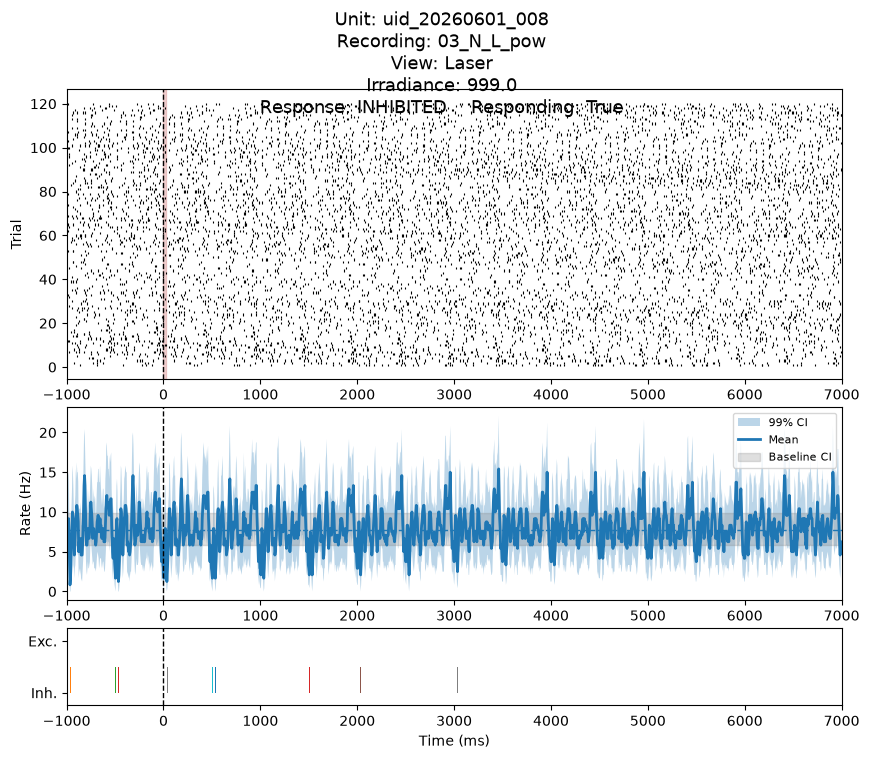

In [29]:
#28
# ==========================================
# Bootstrap response validation
# ==========================================

"""
Visualise the bootstrap response analysis.

The figure contains

1. Raster plot
2. Mean firing rate with 99% bootstrap CI
3. Significant response bins

This cell is intended as a visual sanity check of the
bootstrap algorithm before population analyses.
"""

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ------------------------------------------
# Plot each available view
# ------------------------------------------

for view in analysis_views:

    view_name = view["name"]

    group_label = view["group_label"]

    result = bootstrap_response[view_name]

    fig = plt.figure(
        figsize=(10, 8)
    )

    gs = GridSpec(
        3,
        1,
        height_ratios=[3, 2, 0.8],
        hspace=0.15,
    )

    ax_raster = fig.add_subplot(gs[0])
    ax_rate = fig.add_subplot(gs[1], sharex=ax_raster)
    ax_sig = fig.add_subplot(gs[2], sharex=ax_raster)

    # ======================================
    # Raster
    # ======================================

    trial = 0

    for train_id in sorted(all_spiketimes[view_name]):

        for spiketrain in all_spiketimes[view_name][train_id]:

            ax_raster.vlines(
                spiketrain,
                trial + 0.5,
                trial + 1.5,
                color="black",
                linewidth=0.8,
            )

            trial += 1

    ax_raster.set_ylabel("Trial")

    # draw stimulus windows

    row = burst_df.query(
        "train_id == @train_id"
    ).iloc[0]

    group_column = view["group_column"]
    group_value = row[group_column]

    _, windows = view["stim_windows"](row)

    for x0, x1, stim_name in windows:

        if stim_name == "Polychrome":
            color = "royalblue"
        else:
            color = "firebrick"

        ax_raster.axvspan(
            x0,
            x1,
            alpha=0.2,
            color=color,
        )

    # ======================================
    # Firing rate
    # ======================================

    ax_rate.fill_between(

        result["bin_centres"],

        result["ci_low"],

        result["ci_high"],

        alpha=0.3,

        label="99% CI",

    )

    ax_rate.plot(

        result["bin_centres"],

        result["mean_rate"],

        linewidth=2,

        label="Mean",

    )

    ax_rate.axhspan(

        result["baseline_low"],

        result["baseline_high"],

        color="grey",

        alpha=0.25,

        label="Baseline CI",

    )

    ax_rate.axhline(

        result["baseline_rate"],

        linestyle="--",

        linewidth=1,

    )

    ax_rate.set_ylabel("Rate (Hz)")

    ax_rate.legend(
        fontsize=8,
    )

    # ======================================
    # Significant bins
    # ======================================

    ax_sig.set_ylim(-1.5, 1.5)

    ax_sig.set_yticks(
        [-1, 1]
    )

    ax_sig.set_yticklabels(
        [
            "Inh.",
            "Exc.",
        ]
    )

    for centre, excited in zip(
        result["bin_centres"],
        result["excited_bins"],
    ):

        if excited:

            ax_sig.bar(

                centre,

                1,

                width=bin_step,

            )

    for centre, inhibited in zip(
        result["bin_centres"],
        result["inhibited_bins"],
    ):

        if inhibited:

            ax_sig.bar(

                centre,

                -1,

                width=bin_step,

            )

    ax_sig.set_xlabel(
        "Time (ms)"
    )

    # ======================================
    # Cosmetics
    # ======================================

    for ax in (
        ax_raster,
        ax_rate,
        ax_sig,
    ):

        ax.axvline(
            0,
            color="black",
            linestyle="--",
            linewidth=1,
        )

        ax.set_xlim(
            analysis_window
        )

    response = result["response_type"]

    responding = result["responding"]

    fig.suptitle(

        f"Unit: {unit_id}\n"
        f"Recording: {rec_id}\n"
        f"View: {view_name}\n"
        f"{group_label}: {group_value}\n"
        f"Response: {response.upper()}    "
        f"Responding: {responding}",

        fontsize=13,

    )

    plt.show()

### 9. Population analysis

### Appendix: Debugging

In [30]:
from pathlib import Path
from pv_chip_aarhus.preprocessing.params import dataset_dir

sid = "20260601_eye1_1st"

trigger_dir = Path(dataset_dir) / sid / "trigger_files"
stim_dir = Path(dataset_dir) / sid / "stim_files"

print("Trigger files:")
for f in sorted(trigger_dir.glob("*_triggers.pkl")):
    print(f.name)

print("\nStim files:")
for f in sorted(stim_dir.glob("*.dat")):
    print(f.name)

Base exists: True
Session exists: True

Expected session directory:
D:\ACJ\20260601\20260601 PV chip rd1 770 eye1 1st half\Analysis\raw_filtered\20260601_eye1_1st

Session contents:
misc
sorting_files
stim_files
trigger_files
Trigger files:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_01_1-pow_N_P_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_02_1-pow_N_P_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_03_2-pow_N_L_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_04_3-pow_LC_B_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_05_4-dur_N_P_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_06_4-dur_N_P_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_07_5-dur_N_L_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_08_6-dur_LC_B_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_09_7-freq_N_P_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_10_8-freq_N_L_triggers.pkl
20260601_PV_chip_rd1_770_eye1_1st_half_rec_11_9-freq_LC_B_trigger

In [31]:
from pv_chip_aarhus.preprocessing.lib.filepaths import FilePaths

sid = "20260601_eye1_1st"

filepaths = FilePaths(sid)

    20260601_PV_chip_rd1_770_eye1_1st_half_rec_01_1-pow_N_P_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_02_1-pow_N_P_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_03_2-pow_N_L_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_04_3-pow_LC_B_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_05_4-dur_N_P_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_06_4-dur_N_P_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_07_5-dur_N_L_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_08_6-dur_LC_B_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_09_7-freq_N_P_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_10_8-freq_N_L_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_11_9-freq_LC_B_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_12_10-del_N_B_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half_rec_13_11-del2_N_B_triggers.pkl
    20260601_PV_chip_rd1_770_eye1_1st_half

In [32]:
display(filepaths.recording_table)

,trigger_file,stim_file,lasermode,stimsource,laser_ch,varied_param
01,20260601_PV_chip_rd1_770_eye1_1st_half_rec_01_...,01_pow_N_P_01-06-2026_ch8_eye1_1st_half.dat,N,P,ch8,pow
02,20260601_PV_chip_rd1_770_eye1_1st_half_rec_02_...,01_pow_N_P_01-06-2026_ch8_eye1_1st_half.dat,N,P,ch8,pow
03,20260601_PV_chip_rd1_770_eye1_1st_half_rec_03_...,02_pow_N_L_01-06-2026_ch8_eye1_1st_half.dat,N,L,ch8,pow
04,20260601_PV_chip_rd1_770_eye1_1st_half_rec_04_...,03_pow_LC_B_01-06-2026_ch8_eye1_1st_half.dat,LC,B,ch8,pow
05,20260601_PV_chip_rd1_770_eye1_1st_half_rec_05_...,04_dur_N_P_01-06-2026_ch8_eye1_1st_half.dat,N,P,ch8,dur
06,20260601_PV_chip_rd1_770_eye1_1st_half_rec_06_...,04_dur_N_P_01-06-2026_ch8_eye1_1st_half.dat,N,P,ch8,dur
07,20260601_PV_chip_rd1_770_eye1_1st_half_rec_07_...,05_dur_N_L_01-06-2026_ch8_eye1_1st_half.dat,N,L,ch8,dur
08,20260601_PV_chip_rd1_770_eye1_1st_half_rec_08_...,06_dur_LC_B_01-06-2026_ch8_eye1_1st_half.dat,LC,B,ch8,dur
09,20260601_PV_chip_rd1_770_eye1_1st_half_rec_09_...,07_freq_N_P_01-06-2026_ch8_eye1_1st_half.dat,N,P,ch8,freq
10,20260601_PV_chip_rd1_770_eye1_1st_half_rec_10_...,08_freq_N_L_01-06-2026_ch8_eye1_1st_half.dat,N,L,ch8,freq


In [33]:
from pathlib import Path
from pv_chip_aarhus.preprocessing.params import dataset_dir

sid = "20260601_eye1_1st"

trigger_dir = (
    Path(dataset_dir)
    / sid
    / "trigger_files"
)

print("Trigger directory:")
print(trigger_dir)

for file in trigger_dir.iterdir():
    if "_triggers.pkl" in file.name:
        parts = file.name.split("_")

        print("\nFilename:")
        print(file.name)

        print(f"Number of parts: {len(parts)}")

        for i, part in enumerate(parts):
            print(i, part)

Trigger directory:
D:\ACJ\20260601\20260601 PV chip rd1 770 eye1 1st half\Analysis\raw_filtered\20260601_eye1_1st\trigger_files

Filename:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_01_1-pow_N_P_triggers.pkl
Number of parts: 14
0 20260601
1 PV
2 chip
3 rd1
4 770
5 eye1
6 1st
7 half
8 rec
9 01
10 1-pow
11 N
12 P
13 triggers.pkl

Filename:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_02_1-pow_N_P_triggers.pkl
Number of parts: 14
0 20260601
1 PV
2 chip
3 rd1
4 770
5 eye1
6 1st
7 half
8 rec
9 02
10 1-pow
11 N
12 P
13 triggers.pkl

Filename:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_03_2-pow_N_L_triggers.pkl
Number of parts: 14
0 20260601
1 PV
2 chip
3 rd1
4 770
5 eye1
6 1st
7 half
8 rec
9 03
10 2-pow
11 N
12 L
13 triggers.pkl

Filename:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_04_3-pow_LC_B_triggers.pkl
Number of parts: 14
0 20260601
1 PV
2 chip
3 rd1
4 770
5 eye1
6 1st
7 half
8 rec
9 04
10 3-pow
11 LC
12 B
13 triggers.pkl

Filename:
20260601_PV_chip_rd1_770_eye1_1st_half_rec_05_4-dur_N_P